In [37]:
using DifferentialEquations, LinearAlgebra, SparseArrays, KLU, IterativeSolvers, SparseConnectivityTracer, ADTypes
using Plots
using YAML

# Load the GRI 3.0 mechanism file
data = YAML.load_file("LuMechanism.yaml")

# Function to process chemical data
function process_chemical_data(data)
    species = data["phases"][1]["species"]
    reactions = data["reactions"]
    thermo = data["species"]
    return (species=species, reactions=reactions, thermo=thermo)
end

# Main chemical data object
chem_data = process_chemical_data(data)
thermo = chem_data.thermo
reactions = chem_data.reactions

# Number of species
n_species = length(chem_data.species)

# Species index mapping for easier reference
species_indices = Dict(name => i for (i, name) in enumerate(chem_data.species))

Dict{String, Int64} with 30 entries:
  "CH3OH"  => 21
  "HCCO"   => 27
  "C"      => 9
  "CH"     => 10
  "HCO"    => 17
  "O"      => 3
  "N2"     => 30
  "CH3"    => 13
  "C2H4"   => 24
  "C2H3"   => 23
  "H"      => 2
  "O2"     => 4
  "CH2"    => 11
  "CH2(S)" => 12
  "CO"     => 15
  "CH2CHO" => 29
  "CH2OH"  => 19
  "HO2"    => 7
  "CO2"    => 16
  "OH"     => 5
  "CH4"    => 14
  "C2H6"   => 26
  "C2H2"   => 22
  "CH2CO"  => 28
  "H2O"    => 6
  ⋮        => ⋮

In [38]:
# Chemistry configuration struct with keyword argument support
struct ChemistryConfig
    T::Float64              # Temperature (K)
    pressure::Float64       # Pressure (Pa)
    methane_percentage::Float64  # Methane concentration percentage
    hydrogen_percentage::Float64  # Hydrogen concentration percentage
    air_percentage::Float64      # Air concentration percentage
end


# Constructor with keyword arguments
function ChemistryConfig(; T, pressure, methane_percentage, hydrogen_percentage, air_percentage)
    return ChemistryConfig(T, pressure, methane_percentage, hydrogen_percentage, air_percentage)
end

# Helper function to initialize concentrations
function initialize_concentrations(config, chem_data)
    R = 8.3145  # Universal gas constant (J/mol·K)
    
    # Total concentration (mol/m³)
    c_tot = config.pressure / (R * config.T)

    # cm3
    c_tot = c_tot / 1e6
    
    # Initialize concentration vector
    concentrations = zeros(n_species + 1)
    concentrations[1] = config.T  # Temperature as first element
    
    # Initialize concentrations for each species
    for (i, species) in enumerate(chem_data.species)
        index = i + 1  # Skip temperature in concentration vector
        if species == "N2"
            concentrations[index] = 0.78084 * config.air_percentage * c_tot
        elseif species == "O2"
            concentrations[index] = 0.20946 * config.air_percentage * c_tot
        elseif species == "AR"
            concentrations[index] = 0.00934 * config.air_percentage * c_tot
        elseif species == "CO2"
            concentrations[index] = 0.000412 * config.air_percentage * c_tot
        elseif species == "CH4"
            concentrations[index] = config.methane_percentage * c_tot
        elseif species == "H2"
            concentrations[index] = config.hydrogen_percentage * c_tot
        elseif species == "H2O"
            concentrations[index] = 0.002 * config.air_percentage * c_tot  # Pure guess, needs validation
        elseif species == "CO"
            concentrations[index] = 0.000002 * config.air_percentage * c_tot # Pure guess, needs validation
        else
            concentrations[index] = 0.0  # Default for other species
        end
    end
    
    return concentrations
end

# Initialize concentrations vector
config = ChemistryConfig(T=1000, pressure=10000, methane_percentage=0.1, hydrogen_percentage=0.1, air_percentage=0.8)
X0 = initialize_concentrations(config, chem_data)

31-element Vector{Float64}:
 1000.0
    1.2027181430031873e-7
    0.0
    0.0
    2.015370737867581e-7
    0.0
    1.9243490288050995e-9
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    ⋮
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    0.0
    7.51304347826087e-7

In [39]:
# Atomic accounting check
H=0
O=0
C=0
for i in 1:length(data["species"])
    try 
        H+= data["species"][i]["composition"]["H"]*X0[i+1]
    catch e
        H+=0
    end
    try
        O+= data["species"][i]["composition"]["O"]*X0[i+1]
    catch e
        O+=0
    end
    try
        C+= data["species"][i]["composition"]["C"]*X0[i+1]
    catch e
        C+= 0
    end
end
println("The amount of hydrogen atoms is "*string(H)*" mol")
println("The amount of oxygen atoms is "*string(O)*" mol")
println("The amount of carbon atoms is "*string(C)*" mol")

The amount of hydrogen atoms is 7.254795838595226e-7 mol
The amount of oxygen atoms is 4.057932527512178e-7 mol
The amount of carbon atoms is 1.206701545492814e-7 mol


In [40]:
# Function to process reactions and build stoichiometric matrix and Arrhenius parameters
function build_chemistry_matrices(reactions, species_indices)
    n_species = length(species_indices)
    n_reactions = length(reactions)
    
    # Initialize stoichiometric matrix
    S = zeros(Float64, n_species, n_reactions)
    arrhenius_coeffs = Dict()
    
    for (r_idx, reaction) in enumerate(reactions)
        equation = reaction["equation"]
        equation = replace(equation, " (+ M)"=>""," + M"=>"")
        
        # Determine reaction direction
        if occursin("<=>", equation)
            reactants, products = split(equation, "<=>")
        elseif occursin("=>", equation)
            reactants, products = split(equation, "=>")
        else
            error("Unknown reaction format: $equation")
        end
        
        function parse_species(term)
            species_count = Dict()
            for s in split(strip(term))
                parts = split(s, " ")
                if length(parts) == 2
                    count, species = parse(Float64, parts[1]), parts[2]
                else
                    count, species = 1.0, parts[1]
                end
                species_count[species] = count
            end
            return species_count
        end
        
        reactant_counts = parse_species(reactants)
        product_counts = parse_species(products)
        
        # Populate stoichiometric matrix
        for (species, count) in reactant_counts
            if haskey(species_indices, species)
                S[species_indices[species], r_idx] -= count
            end
        end
        for (species, count) in product_counts
            if haskey(species_indices, species)
                S[species_indices[species], r_idx] += count
            end
        end
        
        # Handle different reaction types
        if haskey(reaction, "type") && reaction["type"] == "three-body"
            rate_constant = reaction["rate-constant"]
            efficiencies = get(reaction, "efficiencies", Dict())
            arrhenius_coeffs[r_idx] = (rate_constant["A"], rate_constant["b"], rate_constant["Ea"], efficiencies)
        elseif haskey(reaction, "type") && reaction["type"] == "falloff"
            lowP = reaction["low-P-rate-constant"]
            highP = reaction["high-P-rate-constant"]
            troe = get(reaction, "Troe", Dict())
            efficiencies = get(reaction, "efficiencies", Dict())
            arrhenius_coeffs[r_idx] = ((lowP["A"], lowP["b"], lowP["Ea"]), troe, efficiencies)
        else
            rate_constant = reaction["rate-constant"]
            arrhenius_coeffs[r_idx] = (rate_constant["A"], rate_constant["b"], rate_constant["Ea"])
        end
    end
    
    return S, arrhenius_coeffs
end

S, arrhenius_coeffs =  build_chemistry_matrices(reactions, species_indices)

([0.0 0.0 … 1.0 0.0; 0.0 -1.0 … -1.0 0.0; … ; 0.0 0.0 … -1.0 -1.0; 0.0 0.0 … 0.0 0.0], Dict{Any, Any}(56 => ((4.36e31, -4.65, 5080.0), Dict{Any, Any}("T3" => 100.0, "A" => 0.6, "T1" => 90000.0, "T2" => 10000.0), Dict{Any, Any}("CO" => 1.5, "CH4" => 2.0, "C2H6" => 3.0, "H2O" => 6.0, "CO2" => 2.0, "H2" => 2.0)), 35 => (2.65e16, -0.6707, 17041.0), 60 => ((4.66e41, -7.44, 14080.0), Dict{Any, Any}("T3" => 100.0, "A" => 0.7, "T1" => 90000.0, "T2" => 10000.0), Dict{Any, Any}("CO" => 1.5, "CH4" => 2.0, "C2H6" => 3.0, "H2O" => 6.0, "CO2" => 2.0, "H2" => 2.0)), 67 => ((3.8e40, -7.27, 7220.0), Dict{Any, Any}("T3" => 98.5, "A" => 0.7507, "T1" => 1302.0, "T2" => 4167.0), Dict{Any, Any}("CO" => 1.5, "CH4" => 2.0, "C2H6" => 3.0, "H2O" => 6.0, "CO2" => 2.0, "H2" => 2.0)), 73 => (2.0e12, 0.0, 0.0), 115 => (5.0e13, 0.0, 0.0), 112 => (1.5e14, 0.0, 23600.0), 86 => (3.0e13, 0.0, 0.0), 168 => (6.82e10, 0.25, -935.0), 177 => (1.2e13, 0.0, 0.0)…))

In [41]:
# Function to extract NASA7 coefficients from the YAML data
function get_species_thermo_data(species_name, thermo)
    for species in thermo
        if species["name"] == species_name
            return species["thermo"]
        end
    end
    error("Species $species_name not found in YAML data.")
end

# Compute specific heat capacity Cp(T) using NASA polynomials
function species_cp(T, thermo_data)
    coeffs_low = thermo_data["data"][1]
    coeffs_high = thermo_data["data"][2]
    T_switch = thermo_data["temperature-ranges"][2]  # The mid-point for NASA polynomials

    if T < T_switch
        a = coeffs_low  # Use low-temperature coefficients
    else
        a = coeffs_high  # Use high-temperature coefficients
    end

    R = 8.3145  # Gas constant in J/(mol·K)
    Cp_R = a[1] + a[2]*T + a[3]*T^2 + a[4]*T^3 + a[5]*T^4  # Cp/R from NASA polynomials
    return Cp_R * R  
end

# Compute enthalpy h0(T) using NASA polynomials
function h0(T, thermo_data)
    coeffs_low = thermo_data["data"][1]
    coeffs_high = thermo_data["data"][2]
    T_switch = thermo_data["temperature-ranges"][2]

    if T < T_switch
        a = coeffs_low
    else
        a = coeffs_high
    end

    R = 8.3145  # Gas constant in J/(mol·K)
    H_RT = a[1] + a[2]*T/2 + a[3]*(T^2)/3 + a[4]*(T^3)/4 + a[5]*(T^4)/5 + a[6]/T
    return H_RT * R * T 
end

# Compute enthalpy h0(T) using NASA polynomials
function entrophy(T, thermo_data)
    coeffs_low = thermo_data["data"][1]
    coeffs_high = thermo_data["data"][2]
    T_switch = thermo_data["temperature-ranges"][2]

    if T < T_switch
        a = coeffs_low
    else
        a = coeffs_high
    end

    R = 8.3145  # Gas constant in J/(mol·K)
    S_R = a[1] * log(T) + a[2]*T + a[3]*(T^2)/2 + a[4]*(T^3)/3 + a[5]*(T^4)/4 + a[7]
    return S_R * R
end

# Compute the temperature rate of change due to reaction enthalpy
function dT(X, r, thermo, S)
    h0_vec = []
    cp_vec = []

    for i in 1:length(X)-1
        species_name = thermo[i]["name"]
        thermo_data = get_species_thermo_data(species_name, thermo)
        
        push!(h0_vec, h0(X[1], thermo_data))  # Enthalpy in kJ/mol
        push!(cp_vec, species_cp(X[1], thermo_data))  # Cp in kJ/mol·K
    end

    dH = sum(-S * r .* h0_vec)  # kJ/s
    c_p = sum(X[2:end] .* cp_vec) / sum(X[2:end])  # kJ/mol·K
    dT = dH / c_p  # K/s
    return dT
end

dT (generic function with 1 method)

In [42]:
function Arrhenius(X, S, arrhenius_coeffs, species_indices, reactions, thermo)
    R = 1.987  # cal/(mol·K), universal gas constant
    n_reactions = length(arrhenius_coeffs)
    r = zeros(n_reactions)  # Initialize reaction rates

    for (i, coeff_data) in arrhenius_coeffs
        if typeof(coeff_data) <: Tuple{Number, Number, Number}
            # -------- Elementary Reactions --------
            A, b, Ea = coeff_data
            # Compute rate constant k
            k = A * X[1]^b * exp(-Ea / (X[1] * R))

        elseif typeof(coeff_data) <: Tuple{Number, Number, Number, Dict}
            # -------- Three-Body Reactions --------
            A, b, Ea, efficiencies = coeff_data

            # Compute k as usual
            k = A * X[1]^b * exp(-Ea / (X[1] * R))

            # Apply efficiency factor
            factor = 1.0
            for (species, eff) in efficiencies
                if haskey(species_indices, species)
                    factor += eff * X[species_indices[species]]
                end
            end
            k *= factor

        elseif typeof(coeff_data) <: Tuple{Tuple, Dict, Dict}
            # -------- Falloff Reactions (Low-P Only) --------
            (lowP_A, lowP_b, lowP_Ea), troe, efficiencies = coeff_data

            # Compute low-pressure rate constant (ONLY low-P limit)
            k = lowP_A * X[1]^lowP_b * exp(-lowP_Ea / (X[1] * R))

            # Compute third-body concentration
            third_body_conc = 1.0
            for (species, eff) in efficiencies
                if haskey(species_indices, species)
                    third_body_conc += eff * X[species_indices[species]]
                end
            end

            k *= third_body_conc  # Apply third-body enhancement

        else
            error("Unknown reaction type for reaction index $i")
        end

        # Compute reactant term
        reactant_term = 1.0
        for j in 1:size(S, 1)
            if S[j, i] < 0
                reactant_term *= abs(X[j+1])^-S[j, i]
            end
        end
        r[i] = k * reactant_term

        if occursin( "<=>", reactions[i]["equation"]) #account for reverse reactions
            delta_H = 0
            delta_S = 0
            for j in 1:size(S, 1)
                if S[j, i] != 0
                    species_name = thermo[j]["name"]
                    thermo_data = get_species_thermo_data(species_name, thermo)
                    delta_H += S[j,i] * h0(X[1],thermo_data)
                    delta_S += S[j,i] * entrophy(X[1],thermo_data)
                end
            end
            k_rev = k / exp(-(delta_H - X[1] * delta_S) / R / X[1])
            product_term = 1.0
            for j in 1:size(S, 1)
                if S[j, i] > 0
                    product_term *= abs(X[j+1])^S[j, i]
                end
            end
            r[i] -= k_rev * product_term
        end        
    end

    return r
end

Arrhenius (generic function with 1 method)

In [49]:
# Convert S to a sparse matrix
S_sparse = sparse(S)
params = (S_sparse, arrhenius_coeffs, species_indices, reactions, thermo)

function reaction_ode!(dX, X, p, t)
    S, arrhenius_coeffs, species_indices, reactions, thermo = p

    for xi in X
        if xi <= 1e-60 
            xi = 0
        end
    end

    # Compute reaction rates
    r = Arrhenius(X, S, arrhenius_coeffs, species_indices, reactions, thermo)

    # Update temperature and species concentrations
    dX[1] = dT(X, r, thermo, S)
    dX[2:end] .= S * r
end

# Define time span and solver settings
tspan = (0.0, 1e-6)
abstol, reltol = 1e-9, 1e-3

# Set up and solve the ODE problem
problem = ODEProblem(reaction_ode!, X0, tspan, params)
sol = solve(problem,
            QNDF(autodiff=false), 
            abstol=abstol, reltol=reltol)

┌ Warning: At t=3.4678482787212544e-11, dt was forced below floating point epsilon 6.462348535570529e-27, and step error estimate = 0.6193944160241655. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase C:\Users\jelte\.julia\packages\SciMLBase\Pma4a\src\integrator_interface.jl:623


retcode: Unstable
Interpolation: 3rd order Hermite
t: 31-element Vector{Float64}:
 0.0
 2.2578274138475148e-23
 2.483610155232266e-22
 2.5061884293707416e-21
 2.508446256784589e-20
 2.508672039525974e-19
 2.508694617800112e-18
 2.5086968756275258e-17
 2.508697101410267e-16
 2.508697123988541e-15
 2.5086971262463685e-14
 2.508697126472151e-13
 2.5086971264947295e-12
 ⋮
 3.467848278720224e-11
 3.4678482787203005e-11
 3.4678482787210657e-11
 3.467848278721185e-11
 3.467848278721223e-11
 3.467848278721237e-11
 3.467848278721245e-11
 3.467848278721249e-11
 3.467848278721251e-11
 3.4678482787212524e-11
 3.467848278721254e-11
 3.4678482787212544e-11
u: 31-element Vector{Vector{Float64}}:
 [1000.0, 1.2027181430031873e-7, 0.0, 0.0, 2.015370737867581e-7, 0.0, 1.9243490288050995e-9, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 7.51304347826087e-7]
 [1000.0000000000001, 1.2027181430031875e-7, 1.4783390329201462e-28, 6.591835872936066e-40, 2.0153707378675812e-7, -2.759369932352506

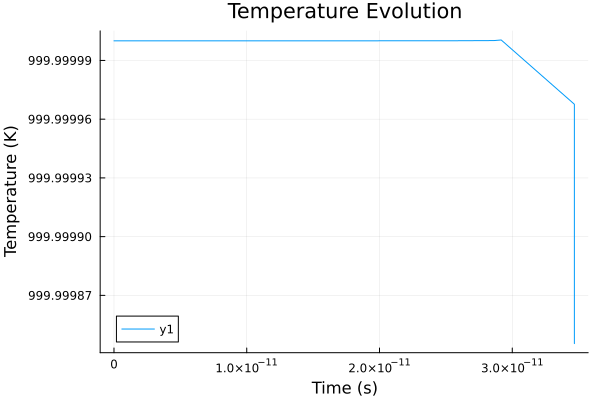

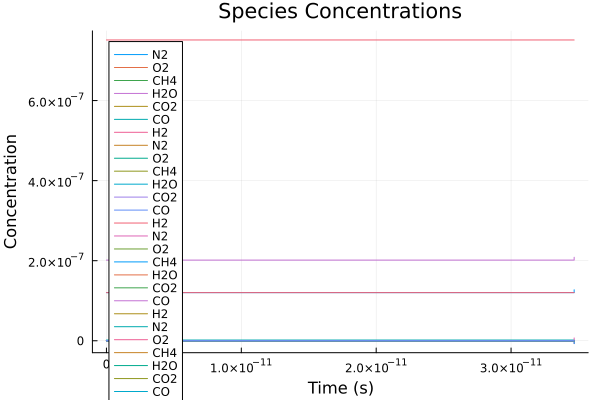

In [50]:
# Extract the solution arrays
t = sol.t
T = sol[1, :]
C = sol[2:end, :]'

# Create a plot for the temperature
plot1 = plot(t, T, xlabel="Time (s)", ylabel="Temperature (K)", title="Temperature Evolution")

display(plot1)

# Create a plot for the species concentrations
plot2 = plot(t, C, xlabel="Time (s)", ylabel="Concentration", title="Species Concentrations", label=["N2" "O2" "CH4" "H2O" "CO2" "CO" "H2"])

display(plot2)